# Respostas Temporais — Mola Não-Linear e Sistema de 1ª Ordem

Tradução em Python dos scripts MATLAB da pasta `Listas_exs`
(`lista1_ex5_1.m`, `lista1_ex5_2.m`, `resposta_temporal_1a_ordem.m`).

As duas primeiras seções simulam um sistema massa-mola-amortecedor com **mola cúbica
não-linear** ($F_k = Ky^3$) sob excitação harmônica, comparando a resposta não-linear
(integrada numericamente) com a de sistemas linearizados em torno de diferentes pontos de
operação. A terceira seção resolve a resposta ao degrau de um sistema de 1ª ordem
(típico de manobra/guinada de embarcação, $M\dot v = -Bv + F$).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

## 1. Mola cúbica com pré-carga estática (`lista1_ex5_1.m`)

Massa $M$ suspensa por uma mola não-linear $F_k(y)=K(y+y_0)^3$, em equilíbrio estático sob
o peso próprio $P=Mg$ (deslocamento estático $y_0=(P/K)^{1/3}$), sujeita a uma força de
excitação harmônica adicional $f(t)=A\cos t$:
$$M\ddot y = P + f(t) - B\dot y - K(y+y_0)^3$$
Essa equação é comparada com sua **linearização** em torno de $y=0$ (pequenas oscilações
ao redor do equilíbrio estático), com rigidez equivalente $k_{eq}=3Ky_0^2$:
$$M\ddot y = f(t) - B\dot y - k_{eq}\,y$$

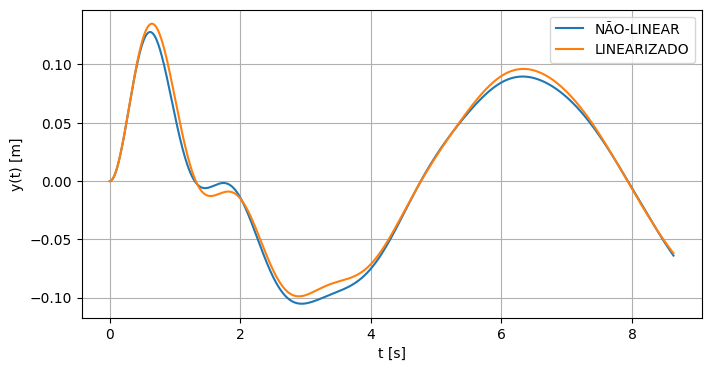

In [3]:
# PARÂMETROS
g = 9.81   # m/s^2
M = 10     # kg
B = 16     # N.s/m
K = 40     # N/m^3

# FORÇA DE EXCITAÇÃO
A = 20
f_exc = lambda t: A * np.cos(t)

# CÁLCULOS
P = M * g
y0 = (P / K) ** (1 / 3)
keq = 3 * K * y0 ** 2
t_final = -2 * M / B * np.log(0.001)   # y/y0(t) ~ e^(-B/2M t) == t ~ -2M/B ln(y/y0)
tspan = (0, t_final)
t_eval = np.linspace(*tspan, 1000)
init = [0.0, 0.0]


def odefun1(t, y):
    """Sistema não-linear."""
    return [y[1], (P + f_exc(t) - B * y[1] - K * (y[0] + y0) ** 3) / M]


def odefun2(t, y):
    """Sistema linearizado (keq)."""
    return [y[1], (f_exc(t) - B * y[1] - keq * y[0]) / M]


sol1 = solve_ivp(odefun1, tspan, init, t_eval=t_eval, rtol=1e-8, atol=1e-8)
sol2 = solve_ivp(odefun2, tspan, init, t_eval=t_eval, rtol=1e-8, atol=1e-8)

plt.figure(figsize=(8, 4))
plt.plot(sol1.t, sol1.y[0], label='NÃO-LINEAR')
plt.plot(sol2.t, sol2.y[0], label='LINEARIZADO')
plt.xlabel('t [s]')
plt.ylabel('y(t) [m]')
plt.legend()
plt.grid(True)
plt.show()

## 2. Mola cúbica sem pré-carga — duas linearizações (`lista1_ex5_2.m`)

Mesmo sistema massa-mola-amortecedor cúbico, agora oscilando em torno de $x=0$ (sem
pré-carga estática):
$$M\ddot x = f(t) - B\dot x - Kx^3$$
Comparam-se três modelos:
- **Não-linear**: a equação completa acima;
- **Linear (ingênua)**: desprezando completamente a mola ($K=0$);
- **Linear (melhor)**: rigidez equivalente $K_{eq}$ obtida por um balanço de energia,
  igualando o trabalho da força não-linear e da linearizada para uma oscilação de
  amplitude estimada $\delta=(A/K)^{1/3}$: $K_{eq} = \tfrac{3}{4}K\delta^2$.

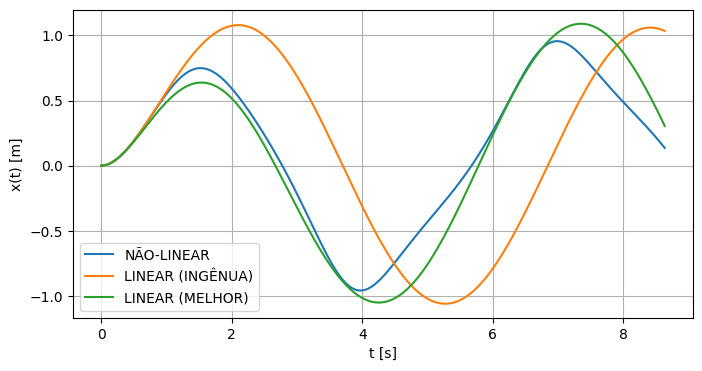

In [4]:
g = 9.81
M = 10
B = 16
K = 40

A = 20
f_exc = lambda t: A * np.cos(t)

t_final = -2 * M / B * np.log(0.001)
tspan = (0, t_final)
t_eval = np.linspace(*tspan, 1000)
x0_init = [0.0, 0.0]

# LINEARIZAÇÃO MELHOR: "E_mola = Fk(x)*x = Fk_lin(x)*x", com x0=0 oscilando como delta*cos(t):
# <K*delta^3*delta> = <Keq*delta*delta> => K*(3/8)*delta^4 = Keq*(1/2)*delta^2
delta = (A / K) ** (1 / 3)   # boa estimativa da amplitude
Keq = K * (3 / 4) * delta ** 2


def odefun1(t, x):
    """Sistema não-linear."""
    return [x[1], (f_exc(t) - B * x[1] - K * x[0] ** 3) / M]


def odefun2(t, x):
    """Sistema linearizado (ingênuo, sem mola)."""
    return [x[1], (f_exc(t) - B * x[1]) / M]


def odefun3(t, x):
    """Sistema linearizado (melhor, com Keq)."""
    return [x[1], (f_exc(t) - B * x[1] - Keq * x[0]) / M]


sol1 = solve_ivp(odefun1, tspan, x0_init, t_eval=t_eval, rtol=1e-8, atol=1e-8)
sol2 = solve_ivp(odefun2, tspan, x0_init, t_eval=t_eval, rtol=1e-8, atol=1e-8)
sol3 = solve_ivp(odefun3, tspan, x0_init, t_eval=t_eval, rtol=1e-8, atol=1e-8)

plt.figure(figsize=(8, 4))
plt.plot(sol1.t, sol1.y[0], label='NÃO-LINEAR')
plt.plot(sol2.t, sol2.y[0], label='LINEAR (INGÊNUA)')
plt.plot(sol3.t, sol3.y[0], label='LINEAR (MELHOR)')
plt.xlabel('t [s]')
plt.ylabel('x(t) [m]')
plt.legend()
plt.grid(True)
plt.show()

## 3. Resposta temporal de 1ª ordem (`resposta_temporal_1a_ordem.m`)

Sistema de 1ª ordem típico de manobra de embarcação, com dois termos de amortecimento
($B$, do próprio corpo, e $C$, de um controlador/realimentação) conduzindo a resposta a um
valor de referência $y_r$:
$$M\dot y = -(B+C)\,y + C\,y_r$$

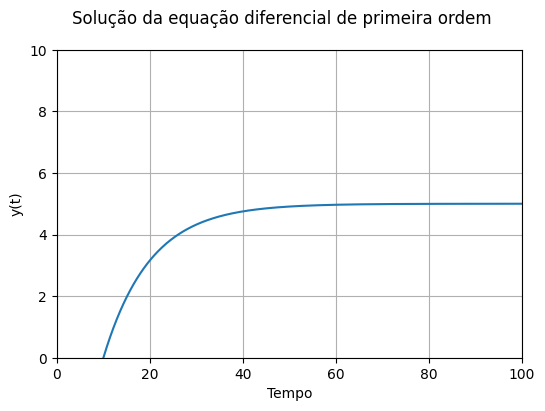

In [5]:
M = 10    # Massa
B = 0.5   # Amortecimento
C = 0.5
y_r = 10  # Valor final (referência)

f_ode = lambda t, y: (-(B + C) * y + C * y_r) / M

tspan = (10, 100)
y0 = [0.0]

sol = solve_ivp(f_ode, tspan, y0, dense_output=True, rtol=1e-8, atol=1e-8)
t = np.linspace(*tspan, 500)
y = sol.sol(t)[0]

plt.figure(figsize=(6, 4))
plt.plot(t, y)
plt.xlim(0, 100)
plt.ylim(0, 10)
plt.xlabel('Tempo')
plt.ylabel('y(t)')
plt.grid(True)
plt.suptitle('Solução da equação diferencial de primeira ordem')
plt.show()